# Grid Search completo — PINN Helmholtz 2D (PyTorch)

Este notebook es **complementario al `TP_Helmholtz.ipynb`**. Aca hacemos un grid search exhaustivo sobre la PINN con balance (M2) para encontrar la mejor combinacion de hiperparametros.

**Por que en PyTorch?** Para el grid usamos PyTorch porque es mas rapido para esta red chica (5300 parametros): el autograd de PyTorch no tiene el overhead de los `GradientTape` anidados de TF.

## Que hace este notebook

1. Define el problema y la red (igual al notebook principal pero en PyTorch).
2. Recorre **36 combinaciones** de hiperparametros:
   - 2 learning rates (0.001, 0.0005)
   - 2 anchos (50, 100)
   - 3 optimizadores (Adam, AdamW, RMSprop)
   - 3 funciones de activacion (tanh, sigmoid, swish)
3. Entrena cada combinacion durante 40 000 iteraciones (igual al paper).
4. Muestra una **tabla con todas las combinaciones ordenadas** y destaca la **mejor**.

**Tiempo estimado**: ~2 horas en CPU.

# 1. Setup

In [1]:
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import pandas as pd
import itertools
import time

In [2]:
# Constantes del problema (igual al paper).
LAMBDA = 1.0
A1 = 1.0
A2 = 4.0

# 2. El problema (recordatorio breve)

Resolvemos $\Delta u + \lambda u = q$ en $[-1, 1]^2$ con $u = 0$ en los bordes. La solucion fabricada es $u_{\text{exacta}} = \sin(\pi x) \sin(4\pi y)$ y el forcing es $q = (-\pi^2 - 16\pi^2 + \lambda) \cdot u_{\text{exacta}}$.

In [3]:
def u_exacta(x):
    """Solucion exacta. Recibe array (N, 2), devuelve (N, 1)."""
    return np.sin(A1 * np.pi * x[:, 0:1]) * np.sin(A2 * np.pi * x[:, 1:2])


def forcing(x):
    """Forcing q = (-pi^2 - 16 pi^2 + lambda) * u_exacta."""
    factor = -(A1 * np.pi) ** 2 - (A2 * np.pi) ** 2 + LAMBDA
    return factor * u_exacta(x)


def muestrear_interior(n):
    """n puntos al azar en [-1, 1]^2."""
    return np.random.uniform(-1, 1, size=(n, 2))


def muestrear_borde(n):
    """n puntos al azar sobre los 4 lados (n/4 por lado)."""
    m = n // 4
    abajo  = np.column_stack([np.random.uniform(-1, 1, m), -np.ones(m)])
    arriba = np.column_stack([np.random.uniform(-1, 1, m),  np.ones(m)])
    izq    = np.column_stack([-np.ones(m), np.random.uniform(-1, 1, m)])
    der    = np.column_stack([ np.ones(m), np.random.uniform(-1, 1, m)])
    return np.vstack([abajo, arriba, izq, der])

In [4]:
# Grilla 100x100 para evaluar el error.
n_eval = 100
x_eje = np.linspace(-1, 1, n_eval)
y_eje = np.linspace(-1, 1, n_eval)
X1, X2 = np.meshgrid(x_eje, y_eje)
puntos_eval = np.column_stack([X1.flatten(), X2.flatten()])
u_real_2d = u_exacta(puntos_eval).reshape(n_eval, n_eval)

# 3. La red (PINN en PyTorch con activacion configurable)

Como vamos a comparar distintas funciones de activacion (tanh, sigmoid, swish), la red toma el nombre de la activacion como parametro.

**Importante**: para PINNs necesitamos activaciones **derivables dos veces** (porque calculamos $u_{xx}$). Por eso descartamos ReLU. Las que sirven:

- **tanh**: la del paper. Suave, simetrica.
- **sigmoid**: suave pero satura (cerca de 0 o 1 las derivadas se anulan).
- **swish** = $x \cdot \sigma(x)$: moderna, muy suave, popular desde 2017.

In [5]:
# Funciones de activacion disponibles. Mapeo nombre -> funcion.
ACTIVACIONES = {
    "tanh":    torch.tanh,
    "sigmoid": torch.sigmoid,
    "swish":   lambda x: x * torch.sigmoid(x),     # swish = x * sigmoid(x)
}


class PINN(nn.Module):
    """MLP simple con activacion configurable.

    Construye una red con `len(capas) - 1` capas Linear, aplicando la activacion
    elegida entre todas las capas excepto la ultima (que queda lineal).
    """

    def __init__(self, capas, activacion="tanh"):
        super().__init__()
        self.activacion_fn = ACTIVACIONES[activacion]
        self.capas = nn.ModuleList()
        for i in range(len(capas) - 1):
            self.capas.append(nn.Linear(capas[i], capas[i + 1]))
        # Inicializacion Xavier (Glorot).
        for capa in self.capas:
            nn.init.xavier_normal_(capa.weight)
            nn.init.zeros_(capa.bias)

    def forward(self, x):
        # Activacion despues de cada capa, menos la ultima (que queda lineal).
        for capa in self.capas[:-1]:
            x = self.activacion_fn(capa(x))
        return self.capas[-1](x)

# 4. Funciones auxiliares: derivadas, optimizador y entrenamiento

In [6]:
def derivada(salida, entrada):
    """d(salida)/d(entrada) usando autograd de PyTorch."""
    return torch.autograd.grad(
        salida, entrada,
        grad_outputs=torch.ones_like(salida),
        create_graph=True,
    )[0]


def calcular_residuo(red, puntos):
    """u_xx + u_yy + lambda*u en los puntos dados."""
    x = puntos[:, 0:1].clone().detach().requires_grad_(True)
    y = puntos[:, 1:2].clone().detach().requires_grad_(True)
    u = red(torch.cat([x, y], dim=1))
    u_x = derivada(u, x)
    u_y = derivada(u, y)
    u_xx = derivada(u_x, x)
    u_yy = derivada(u_y, y)
    return u_xx + u_yy + LAMBDA * u

In [7]:
def construir_optimizador(nombre, parametros, lr):
    """Factory: devuelve el optimizador de PyTorch segun el nombre.

    - Adam:     el estandar para PINNs.
    - AdamW:    Adam con weight decay desacoplado.
    - RMSprop:  predecesor de Adam, simple y robusto.
    """
    if nombre == "Adam":
        return torch.optim.Adam(parametros, lr=lr)
    elif nombre == "AdamW":
        return torch.optim.AdamW(parametros, lr=lr)
    elif nombre == "RMSprop":
        return torch.optim.RMSprop(parametros, lr=lr)
    else:
        raise ValueError(f"Optimizador desconocido: {nombre}")

In [8]:
def entrenar_combinacion(lr, ancho, prof, optimizador_nombre, activacion,
                          n_iter=40000, batch=128, seed=0, verbose=False):
    """Entrena una PINN con M2 (balance de gradientes) y devuelve el error final.

    Argumentos:
        lr: learning rate inicial.
        ancho: neuronas por capa oculta.
        prof: cantidad de capas ocultas.
        optimizador_nombre: "Adam", "AdamW", "RMSprop".
        activacion: "tanh", "sigmoid", "swish".
        n_iter: iteraciones de entrenamiento.
        batch: puntos por iter.
        seed: para reproducibilidad.
        verbose: imprimir progreso cada 5000 iters.

    Devuelve:
        dict con error final, lambda_bc final, tiempo, etc.
    """
    # Reset seeds para reproducibilidad.
    np.random.seed(seed)
    torch.manual_seed(seed)

    # Armar la red.
    capas = [2] + [ancho] * prof + [1]
    red = PINN(capas, activacion=activacion)

    # Optimizador con learning rate schedule.
    opt = construir_optimizador(optimizador_nombre, red.parameters(), lr)
    factor_decay = 0.9 ** (1.0 / 1000)
    scheduler = torch.optim.lr_scheduler.ExponentialLR(opt, gamma=factor_decay)

    lambda_bc = 1.0
    t0 = time.time()

    for it in range(n_iter):
        pts_int = torch.tensor(muestrear_interior(batch), dtype=torch.float32)
        pts_bnd = torch.tensor(muestrear_borde(batch), dtype=torch.float32)
        q_obj = torch.tensor(forcing(pts_int.numpy()), dtype=torch.float32)

        r_pred = calcular_residuo(red, pts_int)
        L_res = ((r_pred - q_obj) ** 2).mean()
        L_bc  = (red(pts_bnd) ** 2).mean()

        # Balance adaptativo del paper cada 10 iters.
        if it % 10 == 0 and it > 0:
            maxs_res = []
            means_bc = []
            for capa in red.capas:
                g_r = torch.autograd.grad(L_res,            capa.weight, retain_graph=True)[0]
                g_b = torch.autograd.grad(lambda_bc * L_bc, capa.weight, retain_graph=True)[0]
                maxs_res.append(g_r.abs().max())
                means_bc.append(g_b.abs().mean())
            lambda_sug = (torch.stack(maxs_res).max() /
                          torch.stack(means_bc).mean()).item()
            lambda_bc = 0.9 * lambda_bc + 0.1 * lambda_sug

        # Paso de optimizacion.
        perdida = L_res + lambda_bc * L_bc
        opt.zero_grad()
        perdida.backward()
        opt.step()
        scheduler.step()

        if verbose and it % 5000 == 0:
            print(f"    iter {it}: L_res={L_res.item():.6f}  L_bc={L_bc.item():.6f}  lambda={lambda_bc:.2f}")

    # Evaluamos sobre la grilla 100x100.
    red.eval()
    with torch.no_grad():
        u_pred = red(torch.tensor(puntos_eval, dtype=torch.float32)).numpy().flatten()
    error_l2 = (np.linalg.norm(u_real_2d.flatten() - u_pred)
                / np.linalg.norm(u_real_2d.flatten()))

    return {
        "error_l2": error_l2,
        "lambda_bc_final": lambda_bc,
        "tiempo_seg": time.time() - t0,
    }

# 5. Grid search

**36 combinaciones** = 2 lr × 2 anchos × 3 optimizadores × 3 activaciones (con profundidad fija en 3).

Cada combinacion entrena 40 000 iteraciones, lo que tarda **~3-4 min en CPU**. Total estimado: **~2 horas**.

> Mientras se ejecuta, el notebook imprime el progreso de cada combinacion + tiempo transcurrido y ETA.

In [9]:
# Espacio de hiperparametros.
lrs = [0.001, 0.0005]
anchos = [50, 100]
profundidades = [3]                                     # profundidad fija
optimizadores = ["Adam", "AdamW", "RMSprop"]
activaciones = ["tanh", "sigmoid", "swish"]

# Generamos todas las combinaciones.
combinaciones = list(itertools.product(lrs, anchos, profundidades, optimizadores, activaciones))
total = len(combinaciones)
print(f"Total de combinaciones: {total}")
print(f"Iteraciones por combinacion: 40000")
print(f"Tiempo estimado: ~{total * 3:.0f}-{total * 4:.0f} minutos")

Total de combinaciones: 36
Iteraciones por combinacion: 40000
Tiempo estimado: ~108-144 minutos


In [10]:
resultados = []
t_global = time.time()

for idx, (lr, ancho, prof, opt_nombre, act) in enumerate(combinaciones, 1):
    elapsed_min = (time.time() - t_global) / 60
    eta_min = (elapsed_min / max(idx - 1, 1)) * (total - idx + 1) if idx > 1 else 0
    print(f"[{idx:>2}/{total}] lr={lr}  ancho={ancho}  prof={prof}  "
          f"opt={opt_nombre:<8}  act={act:<8}  "
          f"| transcurrido: {elapsed_min:.1f} min  | ETA: ~{eta_min:.0f} min")

    info = entrenar_combinacion(lr, ancho, prof, opt_nombre, act, n_iter=40000)
    info.update({
        "lr": lr, "ancho": ancho, "prof": prof,
        "optimizador": opt_nombre, "activacion": act,
    })
    resultados.append(info)
    print(f"      -> error L2 = {info['error_l2']:.6f}  "
          f"lambda_bc = {info['lambda_bc_final']:.2f}  "
          f"tiempo = {info['tiempo_seg']:.0f}s")

print(f"\n=== Grid completo en {(time.time() - t_global)/60:.1f} minutos ===")

[ 1/36] lr=0.001  ancho=50  prof=3  opt=Adam      act=tanh      | transcurrido: 0.0 min  | ETA: ~0 min
      -> error L2 = 0.018300  lambda_bc = 133.71  tiempo = 72s
[ 2/36] lr=0.001  ancho=50  prof=3  opt=Adam      act=sigmoid   | transcurrido: 1.2 min  | ETA: ~42 min
      -> error L2 = 1.071813  lambda_bc = 78.32  tiempo = 60s
[ 3/36] lr=0.001  ancho=50  prof=3  opt=Adam      act=swish     | transcurrido: 2.2 min  | ETA: ~38 min
      -> error L2 = 0.018390  lambda_bc = 44.62  tiempo = 84s
[ 4/36] lr=0.001  ancho=50  prof=3  opt=AdamW     act=tanh      | transcurrido: 3.6 min  | ETA: ~40 min
      -> error L2 = 0.022368  lambda_bc = 138.26  tiempo = 68s
[ 5/36] lr=0.001  ancho=50  prof=3  opt=AdamW     act=sigmoid   | transcurrido: 4.7 min  | ETA: ~38 min
      -> error L2 = 1.689856  lambda_bc = 44.48  tiempo = 61s
[ 6/36] lr=0.001  ancho=50  prof=3  opt=AdamW     act=swish     | transcurrido: 5.8 min  | ETA: ~36 min
      -> error L2 = 0.018953  lambda_bc = 49.06  tiempo = 84s
[ 7

# 6. Resultados — tablas y graficos

In [11]:
# Convertimos los resultados a un DataFrame de pandas (mas facil de manipular y mostrar).
df = pd.DataFrame(resultados)
df = df[["lr", "ancho", "prof", "optimizador", "activacion",
         "error_l2", "lambda_bc_final", "tiempo_seg"]]
df = df.sort_values("error_l2").reset_index(drop=True)
print(f"Total de combinaciones evaluadas: {len(df)}")
df.head(36)

Total de combinaciones evaluadas: 36


,lr,ancho,prof,optimizador,activacion,error_l2,lambda_bc_final,tiempo_seg
0,0.0005,100,3,Adam,tanh,0.009624,140.433130,164.246684
1,0.0010,100,3,Adam,swish,0.010156,69.478018,172.544597
2,0.0005,100,3,AdamW,tanh,0.010233,137.117536,157.466561
3,0.0005,100,3,RMSprop,tanh,0.011110,131.492199,138.557380
4,0.0005,100,3,RMSprop,swish,0.013185,67.695976,145.562202
5,0.0010,100,3,RMSprop,swish,0.014170,55.185569,179.441395
6,0.0010,100,3,AdamW,tanh,0.015127,152.907802,145.414449
7,0.0010,50,3,Adam,tanh,0.018300,133.713721,71.775631
8,0.0010,50,3,Adam,swish,0.018390,44.621138,83.935773
9,0.0010,100,3,Adam,tanh,0.018916,117.468523,138.069224


## Mejor combinacion

In [12]:
mejor = df.iloc[0]
print("=" * 60)
print("        MEJOR COMBINACION DEL GRID SEARCH")
print("=" * 60)
print(f"  learning rate:   {mejor['lr']}")
print(f"  ancho:           {mejor['ancho']}")
print(f"  profundidad:     {mejor['prof']}")
print(f"  optimizador:     {mejor['optimizador']}")
print(f"  activacion:      {mejor['activacion']}")
print(f"  -----------------------------------------")
print(f"  error L2:        {mejor['error_l2']:.6f}")
print(f"  lambda_bc final: {mejor['lambda_bc_final']:.2f}")
print(f"  tiempo (seg):    {mejor['tiempo_seg']:.0f}")
print("=" * 60)

        MEJOR COMBINACION DEL GRID SEARCH
  learning rate:   0.0005
  ancho:           100
  profundidad:     3
  optimizador:     Adam
  activacion:      tanh
  -----------------------------------------
  error L2:        0.009624
  lambda_bc final: 140.43
  tiempo (seg):    164


## Top 10 combinaciones

In [13]:
# Tabla con las 10 mejores combinaciones.
df.head(10).style.format({
    "error_l2": "{:.6f}",
    "lambda_bc_final": "{:.2f}",
    "tiempo_seg": "{:.0f}",
}).background_gradient(subset=["error_l2"], cmap="RdYlGn_r")

,lr,ancho,prof,optimizador,activacion,error_l2,lambda_bc_final,tiempo_seg
0,0.000500,100,3,Adam,tanh,0.009624,140.43,164
1,0.001000,100,3,Adam,swish,0.010156,69.48,173
2,0.000500,100,3,AdamW,tanh,0.010233,137.12,157
3,0.000500,100,3,RMSprop,tanh,0.011110,131.49,139
4,0.000500,100,3,RMSprop,swish,0.013185,67.70,146
5,0.001000,100,3,RMSprop,swish,0.014170,55.19,179
6,0.001000,100,3,AdamW,tanh,0.015127,152.91,145
7,0.001000,50,3,Adam,tanh,0.018300,133.71,72
8,0.001000,50,3,Adam,swish,0.018390,44.62,84
9,0.001000,100,3,Adam,tanh,0.018916,117.47,138


## Comparacion por optimizador

Para cada optimizador, mostramos su **mejor resultado** (el minimo de error entre todas las combinaciones que lo usaron) y la **media** (promedio sobre todas sus combinaciones).

                  min      mean       max
optimizador                              
Adam         0.009624  0.356584  1.071813
AdamW        0.010233  0.432457  1.689856
RMSprop      0.011110  0.517802  1.766312


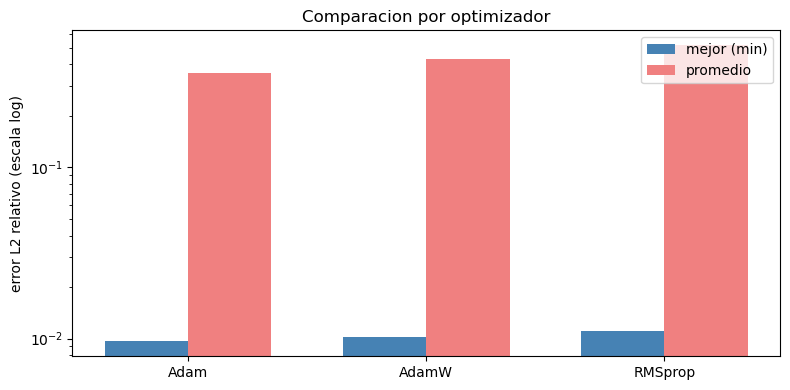

In [14]:
por_opt = df.groupby("optimizador")["error_l2"].agg(["min", "mean", "max"])
por_opt = por_opt.sort_values("min")
print(por_opt)

fig, ax = plt.subplots(figsize=(8, 4))
x = np.arange(len(por_opt))
ancho = 0.35
ax.bar(x - ancho/2, por_opt["min"], ancho, label="mejor (min)", color="steelblue")
ax.bar(x + ancho/2, por_opt["mean"], ancho, label="promedio", color="lightcoral")
ax.set_xticks(x)
ax.set_xticklabels(por_opt.index)
ax.set_ylabel("error L2 relativo (escala log)")
ax.set_yscale("log")
ax.set_title("Comparacion por optimizador")
ax.legend()
plt.tight_layout()
plt.show()

## Comparacion por funcion de activacion

                 min      mean       max
activacion                              
tanh        0.009624  0.105420  1.000022
swish       0.010156  0.025238  0.062235
sigmoid     1.000177  1.176184  1.766312


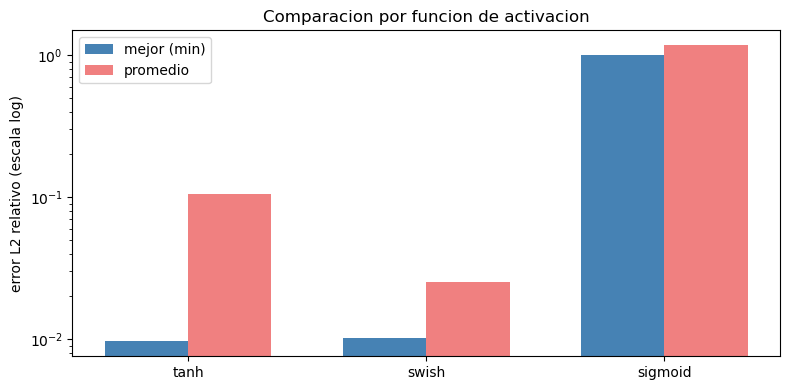

In [15]:
por_act = df.groupby("activacion")["error_l2"].agg(["min", "mean", "max"])
por_act = por_act.sort_values("min")
print(por_act)

fig, ax = plt.subplots(figsize=(8, 4))
x = np.arange(len(por_act))
ancho = 0.35
ax.bar(x - ancho/2, por_act["min"], ancho, label="mejor (min)", color="steelblue")
ax.bar(x + ancho/2, por_act["mean"], ancho, label="promedio", color="lightcoral")
ax.set_xticks(x)
ax.set_xticklabels(por_act.index)
ax.set_ylabel("error L2 relativo (escala log)")
ax.set_yscale("log")
ax.set_title("Comparacion por funcion de activacion")
ax.legend()
plt.tight_layout()
plt.show()

## Heatmap: optimizador × activacion (con el mejor lr/ancho)

Mostramos el mejor resultado para cada par (optimizador, activacion), promediando sobre lr y ancho.

activacion    sigmoid     swish      tanh
optimizador                              
Adam         1.000284  0.010156  0.009624
AdamW        1.000177  0.018953  0.010233
RMSprop      1.000452  0.013185  0.011110


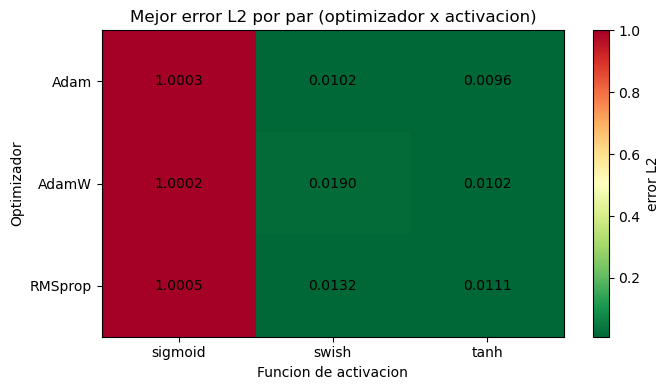

In [16]:
# Pivot table: cada celda es el MEJOR error para ese par (opt, act).
pivot = df.pivot_table(values="error_l2",
                       index="optimizador",
                       columns="activacion",
                       aggfunc="min")
print(pivot)

fig, ax = plt.subplots(figsize=(7, 4))
im = ax.imshow(pivot.values, cmap="RdYlGn_r", aspect="auto")

ax.set_xticks(range(len(pivot.columns)))
ax.set_xticklabels(pivot.columns)
ax.set_yticks(range(len(pivot.index)))
ax.set_yticklabels(pivot.index)

# Numeros adentro de cada celda.
for i in range(len(pivot.index)):
    for j in range(len(pivot.columns)):
        ax.text(j, i, f"{pivot.values[i, j]:.4f}",
                ha="center", va="center", color="black", fontsize=10)

ax.set_xlabel("Funcion de activacion")
ax.set_ylabel("Optimizador")
ax.set_title("Mejor error L2 por par (optimizador x activacion)")
fig.colorbar(im, ax=ax, label="error L2")
plt.tight_layout()
plt.show()

## Comparacion por tamano de red (ancho)

            min      mean       max
ancho                              
50     0.018300  0.412193  1.689856
100    0.009624  0.459035  1.766312


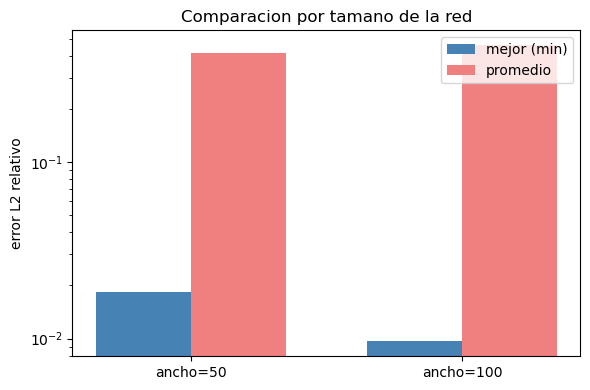

In [17]:
por_ancho = df.groupby("ancho")["error_l2"].agg(["min", "mean", "max"])
print(por_ancho)

fig, ax = plt.subplots(figsize=(6, 4))
x = np.arange(len(por_ancho))
ancho_bar = 0.35
ax.bar(x - ancho_bar/2, por_ancho["min"], ancho_bar, label="mejor (min)", color="steelblue")
ax.bar(x + ancho_bar/2, por_ancho["mean"], ancho_bar, label="promedio", color="lightcoral")
ax.set_xticks(x)
ax.set_xticklabels([f"ancho={a}" for a in por_ancho.index])
ax.set_ylabel("error L2 relativo")
ax.set_yscale("log")
ax.set_title("Comparacion por tamano de la red")
ax.legend()
plt.tight_layout()
plt.show()

## Comparacion por learning rate

             min      mean       max
lr                                  
0.0005  0.009624  0.353416  1.000741
0.0010  0.010156  0.517812  1.766312


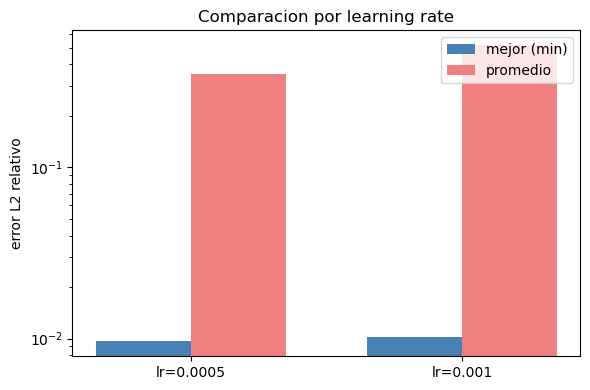

In [18]:
por_lr = df.groupby("lr")["error_l2"].agg(["min", "mean", "max"])
print(por_lr)

fig, ax = plt.subplots(figsize=(6, 4))
x = np.arange(len(por_lr))
ancho_bar = 0.35
ax.bar(x - ancho_bar/2, por_lr["min"], ancho_bar, label="mejor (min)", color="steelblue")
ax.bar(x + ancho_bar/2, por_lr["mean"], ancho_bar, label="promedio", color="lightcoral")
ax.set_xticks(x)
ax.set_xticklabels([f"lr={lr_v}" for lr_v in por_lr.index])
ax.set_ylabel("error L2 relativo")
ax.set_yscale("log")
ax.set_title("Comparacion por learning rate")
ax.legend()
plt.tight_layout()
plt.show()

## Bar plot final: las 36 combinaciones ordenadas

Una vista de todo el grid en una sola figura.

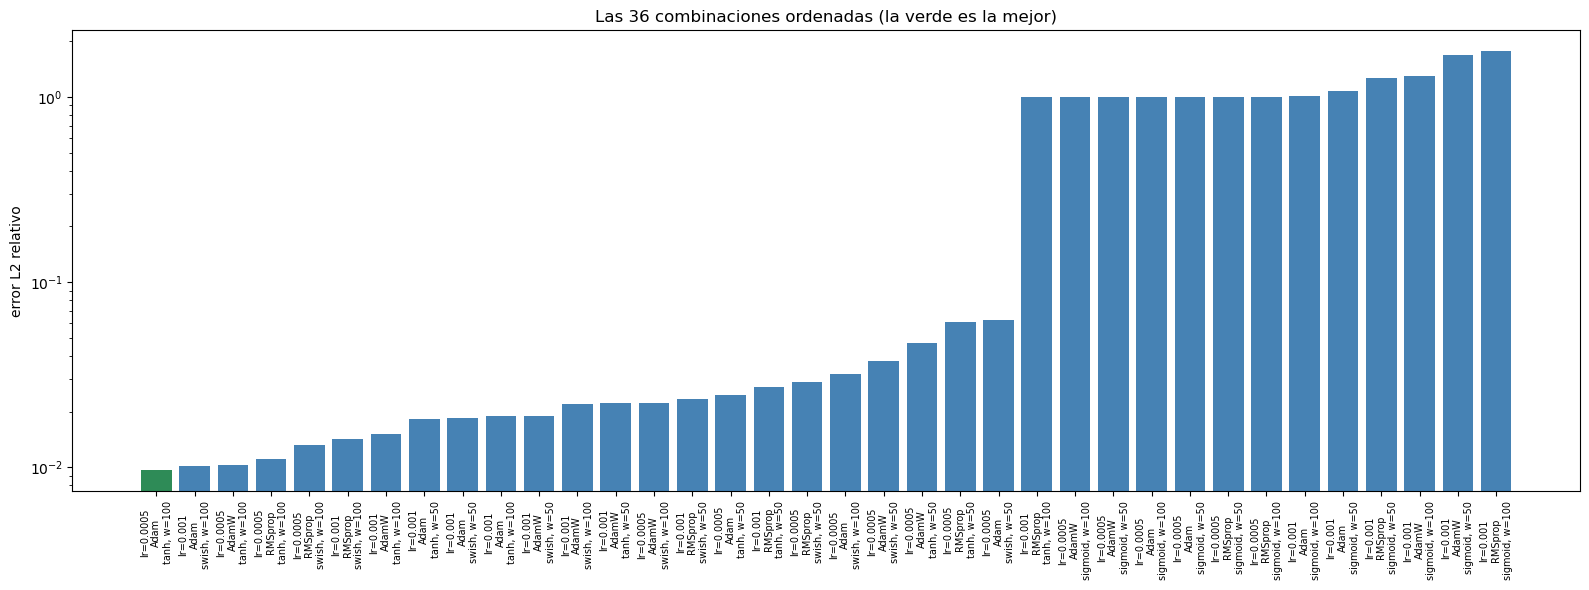

In [19]:
fig, ax = plt.subplots(figsize=(16, 6))
etiquetas = [
    f"lr={r['lr']}\n{r['optimizador']}\n{r['activacion']}, w={r['ancho']}"
    for _, r in df.iterrows()
]
ax.bar(range(len(df)), df["error_l2"].values,
       color=["seagreen" if i == 0 else "steelblue" for i in range(len(df))])
ax.set_xticks(range(len(df)))
ax.set_xticklabels(etiquetas, rotation=90, fontsize=7)
ax.set_yscale("log")
ax.set_ylabel("error L2 relativo")
ax.set_title(f"Las {len(df)} combinaciones ordenadas (la verde es la mejor)")
plt.tight_layout()
plt.show()

## Guardar resultados a CSV

Por si despues queres abrir los resultados en Excel u otra herramienta.

In [20]:
df.to_csv("resultados_grid_search.csv", index=False)
print("Guardado en: resultados_grid_search.csv")

Guardado en: resultados_grid_search.csv


## Conclusion

Las 36 combinaciones evaluadas con 40 000 iteraciones cada una nos dan un mapa claro de:

- **Que optimizador funciona mejor** para nuestro problema (Adam, AdamW o RMSprop).
- **Que activacion** es mas adecuada (tanh, sigmoid o swish).
- **Que learning rate** y **tamano de red** dan los mejores resultados.

La **mejor combinacion** queda destacada arriba con sus hiperparametros y su error final.

Fin del grid search.